/tmp/ipykernel_1220563/3845262060.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


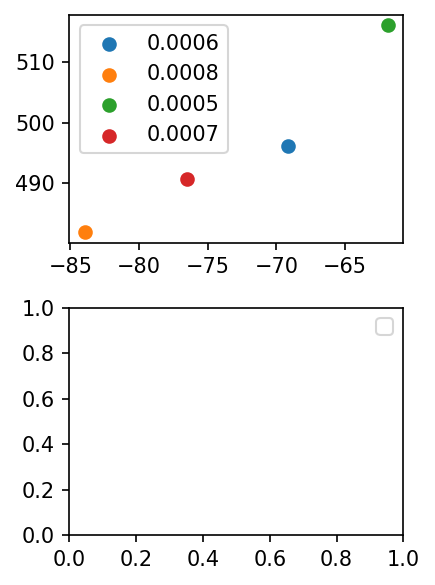

-76.54463655475479


In [17]:
from netCDF4 import Dataset
from sys import argv
import os
import matplotlib.pyplot as plt

plot_var = 'prad'

fig, (ax1,ax2) = plt.subplots(2,1,figsize = (3,4),dpi = 150)

# First just find the fastran.nc file ================
cwd = os.getcwd()
SCAN_dir = cwd+'/SCAN'

#edited to not include 0005 because the fraction of fkr = 0.001 is too high
sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log') and not f.endswith('0005')]
for sim in sims:
    work_dir = SCAN_dir+'/'+sim+'/work'
    fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
    ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
    #=====================================================
    
    rootgrp = Dataset(ffile)
    
    rho = rootgrp['rho'][:]
    try:
        ne = rootgrp['ne'][-1,:]
    except IndexError:
        continue
    nebar = rootgrp['nebar'][-1]
    ni = rootgrp['ni'][-1,:]
    
    te = rootgrp['te'][-1,:]
    teavg = rootgrp['tea'][-1]
    ti = rootgrp['ti'][-1,:]
    tiavg = rootgrp['tia'][-1]
    
    ipol = rootgrp['ipol'][-1,:]
    ip = rootgrp['ip'][-1]
    
    prfe = rootgrp['pe_rf'][-1,:]
    prfi = rootgrp['pi_rf'][-1,:]
    
    pfuse = rootgrp['pe_fus'][-1,:]
    pfuse_int = rootgrp['pfuse'][-1]
    pfusi = rootgrp['pi_fus'][-1,:]
    pfusi_int = rootgrp['pfusi'][-1]
    
    prad = rootgrp['p_rad'][-1,:]
    
    q = rootgrp['q'][-1,:]
    
    jbs = rootgrp['j_bs'][-1,:]
    ibs = rootgrp['ibs'][-1]
    jrf = rootgrp['j_rf'][-1,:]
    irf = rootgrp['irf'][-1]
    jtot = rootgrp['j_tot'][-1,:]
    
    fluxe = rootgrp['fluxe'][-1,:]
    fluxe_exp = rootgrp['fluxe_exp'][-1,:]
    fluxi = rootgrp['fluxi'][-1,:]
    fluxi_exp = rootgrp['fluxi_exp'][-1,:]
    
    var_dic = {'ne':ne,'ni':ni,'te':te,'ti':ti,'ipol':ipol,'jbs':jbs,'jrf':jrf,'pfus':5*(pfuse+pfusi),'paux':prfe+prfi,'prad':prad}
    lw = 2
    c1 = 'green'
    c2 = 'lime'
    c3 = 'magenta'
    c4 = 'darkviolet'
    c5 = 'dodgerblue'
    c6 = 'cyan'

    ax1.scatter(rootgrp['prad'][-1],5*(pfuse_int+pfusi_int),label = rootgrp['nz1'][-1,:][0]/ne[0])
    #ax1.plot(rho,var_dic[plot_var], linewidth = lw,label = rootgrp['prad'][-1])
    #ax2.plot(rho,5*(pfuse+pfusi),label = 5*(pfuse_int+pfusi_int))

fig.tight_layout()
ax1.legend()
ax2.legend()
plt.show()

print(rootgrp['prad'][-1])

In [2]:
print(rootgrp.variables)


{'time': <class 'netCDF4._netCDF4.Variable'>
float64 time(time)
unlimited dimensions: time
current shape = (3,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'rho': <class 'netCDF4._netCDF4.Variable'>
float64 rho(rho)
unlimited dimensions: 
current shape = (101,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'r0': <class 'netCDF4._netCDF4.Variable'>
float64 r0(time)
unlimited dimensions: time
current shape = (3,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'b0': <class 'netCDF4._netCDF4.Variable'>
float64 b0(time)
unlimited dimensions: time
current shape = (3,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'a0': <class 'netCDF4._netCDF4.Variable'>
float64 a0(time)
unlimited dimensions: time
current shape = (3,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'amain': <class 'netCDF4._netCDF4.Variable'>
float64 amain(time)
unlimited dimensions: time
current shape = (3,)
filling on, default _FillValue of 9.96